In [ ]:
!pip install qiskit[visualization]
!pip install qiskit-aer
!pip install qiskit-ibm-runtime
!pip install pylatexenc

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 3.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.7/119.7 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 36.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.5/49.5 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 MB 14.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.5/6.5 MB 62.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.0/109.0 kB 7.3 MB/s eta 0:00:00
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=ce8223b293e80b2780a939210886cd1996c3af9ca3add7d99543a57e78cc7dd9
  Stored in directory: /root/.cache/pip/wheels/b1/7a/33/9fdd892f784ed4afda62b685ae3703adf4c91aa0f524c28f03
Successfully built pylatexenc
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 95.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
from qiskit import QuantumCircuit, transpile
import qiskit.quantum_info as qi
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_histogram
from qiskit_aer import AerSimulator
import numpy as np

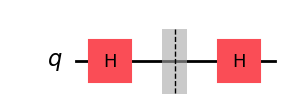

In [ ]:
# Circuito cuantico de interferencia cuantica simple usando compuertad Hadamard #
qc = QuantumCircuit(1)
qc.h(0)
qc.barrier()
qc.h(0)
qc.draw('mpl')

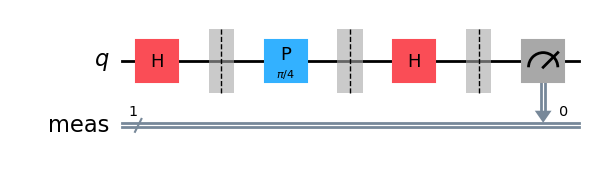

In [ ]:
# Circuito cuantico de interferencia cuantica usando compuerta de fase intermedia #
valores_fase_relativa = [0, np.pi/4, np.pi/2, np.pi] # Corresponden a las compuertas "I", "T", "S" y "Z" dependiendo el valor de \theta.
qc = QuantumCircuit(1)
qc.h(0)
qc.barrier()
qc.p(valores_fase_relativa[1], 0)
qc.barrier()
qc.h(0)
qc.measure_all()
qc.draw('mpl')

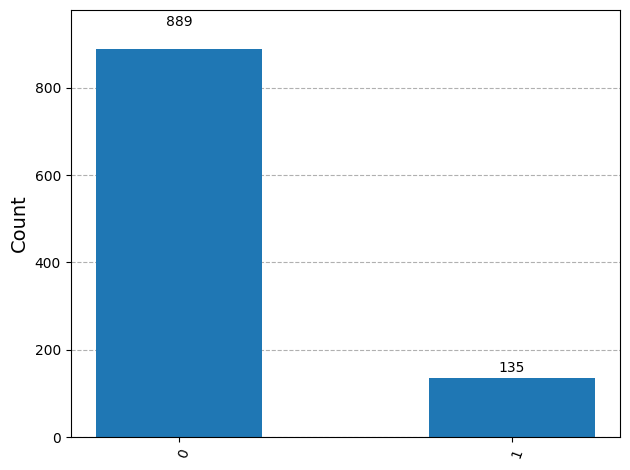

In [ ]:
simulador = AerSimulator()
qc_transpilado = transpile(qc, simulador)
resultado = simulador.run(qc_transpilado, shots=1024).result()
conteo = resultado.get_counts(qc_transpilado)
plot_histogram(conteo)

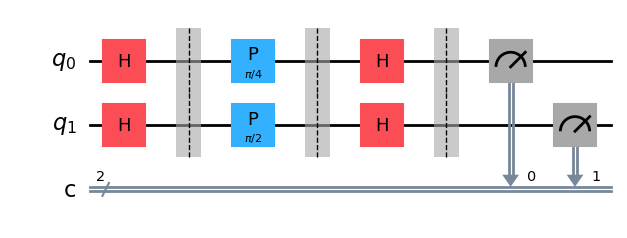

In [ ]:
# Circuito de 2 qubits con compuertas de fase (P) con angulos de fase distinto para cada qubit #
# Parámetros de fase (puedes cambiarlos)
phi_0 = np.pi/4    # fase en el qubit 0
phi_1 = np.pi/2    # fase en el qubit 1

# 1. Crear circuito de 2 qubits y 2 clásicos
qc = QuantumCircuit(2, 2, name='Interf_fases')

# 2. Hadamard iniciales
qc.h([0, 1])
qc.barrier()

# 3. Dos compuertas de fase independientes
qc.p(phi_0, 0)
qc.p(phi_1, 1)
qc.barrier()

# 4. Segunda capa de Hadamard
qc.h([0, 1])
qc.barrier()

# 5. Medición
qc.measure([0, 1], [0, 1])
qc.draw('mpl')


Conteos (1024 tiros):
 {'01': 82, '11': 79, '00': 410, '10': 453}


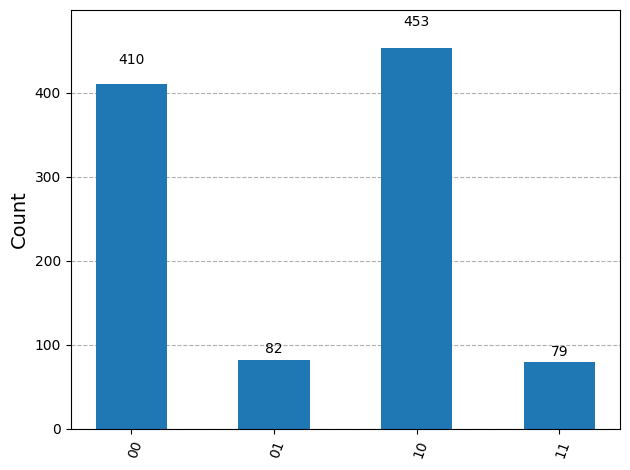

In [ ]:
# Simuladores
sim_state = AerSimulator(method='statevector')
sim_measure = AerSimulator()

# 6. Vector de estado antes de medir
# qc_nomeas = qc.remove_final_measurements(inplace=False)
# qc_nomeas_trans = transpile(qc_nomeas, sim_state)
# result_sv = sim_state.run(qc_nomeas_trans).result()
# state = Statevector(result_sv.get_statevector())
# print("Estado final (vector):\n", state)

# 7. Conteos de medida
qc_meas_trans = transpile(qc, sim_measure)
counts = sim_measure.run(qc_meas_trans, shots=1024).result().get_counts()
print("\nConteos (1024 tiros):\n", counts)
plot_histogram(counts)

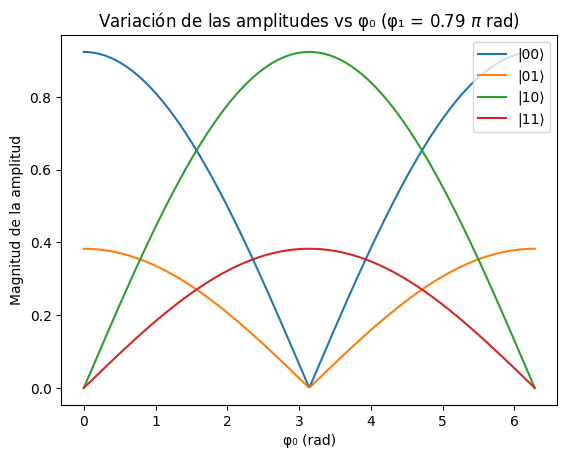

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Definimos la matriz de Hadamard de un qubit y su producto tensorial para 2 qubits
H = 1/np.sqrt(2) * np.array([[1, 1], [1, -1]])
H2 = np.kron(H, H)

# Estado inicial |00>
psi0 = np.array([1, 0, 0, 0], dtype=complex)

# Preparamos el estado tras la primera capa de Hadamard
psi1 = H2 @ psi0

# Barrido de phi0 y valor fijo de phi1 (puedes modificar phi1 y volver a ejecutar)
phi0_vals = np.linspace(0, 2*np.pi, 300)
phi1 = np.pi / 4  # ejemplo de fase para el qubit 1

# Reservamos espacio para las magnitudes de las amplitudes
amplitudes = np.zeros((4, len(phi0_vals)))

# Calculamos el estado final para cada phi0
for i, phi0 in enumerate(phi0_vals):
    # Operadores de fase en cada qubit
    P0 = np.diag([1, 1, np.exp(1j*phi0), np.exp(1j*phi0)])
    P1 = np.diag([1, np.exp(1j*phi1), 1, np.exp(1j*phi1)])
    P = P1 @ P0

    # Estado tras aplicar las fases y la segunda capa de Hadamard
    psi3 = H2 @ (P @ psi1)

    # Guardamos la magnitud de cada amplitud
    amplitudes[:, i] = np.abs(psi3)

# Gráfica: magnitudes de amplitud vs phi0 para los 4 estados base
plt.figure()
labels = ['|00⟩', '|01⟩', '|10⟩', '|11⟩']
for basis_index in range(4):
    plt.plot(phi0_vals, amplitudes[basis_index], label=labels[basis_index])
plt.xlabel('φ₀ (rad)')
plt.ylabel('Magnitud de la amplitud')
plt.title(f'Variación de las amplitudes vs φ₀ (φ₁ = {phi1:.2f} $\pi$ rad)')
plt.legend()

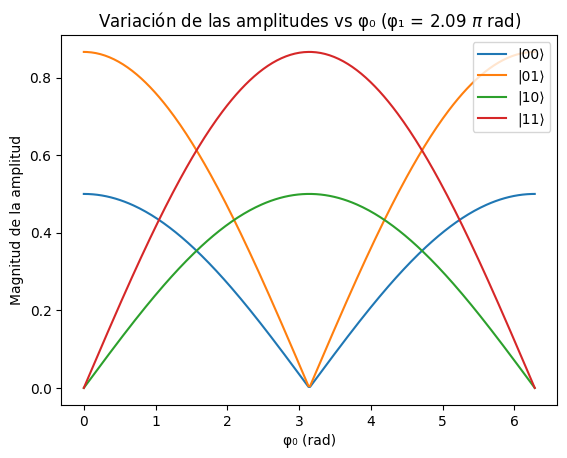

In [ ]:
# Definimos la matriz de Hadamard de un qubit y su producto tensorial para 2 qubits
H = 1/np.sqrt(2) * np.array([[1, 1], [1, -1]])
H2 = np.kron(H, H)

# Estado inicial |00>
psi0 = np.array([1, 0, 0, 0], dtype=complex)

# Preparamos el estado tras la primera capa de Hadamard
psi1 = H2 @ psi0

# Barrido de phi0 y valor fijo de phi1 (puedes modificar phi1 y volver a ejecutar)
phi0_vals = np.linspace(0, 2*np.pi, 300)
phi1 = 2*np.pi/3  # ejemplo de fase para el qubit 1

# Reservamos espacio para las magnitudes de las amplitudes
amplitudes = np.zeros((4, len(phi0_vals)))

# Calculamos el estado final para cada phi0
for i, phi0 in enumerate(phi0_vals):
    # Operadores de fase en cada qubit
    P0 = np.diag([1, 1, np.exp(1j*phi0), np.exp(1j*phi0)])
    P1 = np.diag([1, np.exp(1j*phi1), 1, np.exp(1j*phi1)])
    P = P1 @ P0

    # Estado tras aplicar las fases y la segunda capa de Hadamard
    psi3 = H2 @ (P @ psi1)

    # Guardamos la magnitud de cada amplitud
    amplitudes[:, i] = np.abs(psi3)

# Gráfica: magnitudes de amplitud vs phi0 para los 4 estados base
plt.figure()
labels = ['|00⟩', '|01⟩', '|10⟩', '|11⟩']
for basis_index in range(4):
    plt.plot(phi0_vals, amplitudes[basis_index], label=labels[basis_index])
plt.xlabel('φ₀ (rad)')
plt.ylabel('Magnitud de la amplitud')
plt.title(f'Variación de las amplitudes vs φ₀ (φ₁ = {phi1:.2f} $\pi$ rad)')
plt.legend()